# Análise estatística descritiva do Titanic

## Sobrevivência e classe de passagem

**Colab final da apresentação — Cauany · Bruna · Samuel · Nikson · Kevin**

Este notebook reúne os cálculos e o gráfico usados na apresentação. A análise é descritiva: ela resume os 891 registros do arquivo `train.csv` e observa a associação entre `Pclass` e `Survived`; não demonstra causalidade.

**Fonte única dos cálculos:** este notebook importa `app/api/app/analysis_core.py`, o mesmo módulo Python usado pela API que alimenta o frontend. Assim, tabelas, indicadores e gráficos partem da mesma base e das mesmas fórmulas.

**Fonte dos dados:** arquivo `train.csv` da competição *Titanic - Machine Learning from Disaster*, Kaggle.

## Mapa do notebook e da fala

| Parte | Integrante | O que explica |
|---|---|---|
| Introdução | Cauany | Base, objetivo e significado das variáveis |
| Medidas de posição | Cauany | Média, moda e mediana de `Survived` e `Pclass` |
| Dispersão da classe | Bruna | Desvio padrão e coeficiente de variação de `Pclass` |
| Dispersão da sobrevivência | Samuel | Desvio padrão e coeficiente de variação de `Survived` |
| Relação entre variáveis | Nikson | Tabela cruzada e taxas dentro de cada classe |
| Conclusão | Kevin | Síntese, limites e fontes |

**Regra de leitura:** tabelas apresentam os valores; o gráfico final ajuda a enxergar a diferença entre as taxas por classe.

## 1. Preparação do ambiente — Cauany

As bibliotecas abaixo são usadas para calcular, organizar e visualizar os resultados. A configuração visual é aplicada uma única vez para que as tabelas e o gráfico tenham a mesma identidade.

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'train.csv').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Abra o notebook a partir do repositório, onde está train.csv.')
sys.path.insert(0, str(PROJECT_ROOT / 'app' / 'api'))
from app.analysis_core import analysis_tables, metric_payloads, source_frame

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except ImportError:
    # O Colab normalmente já traz Seaborn; o fallback mantém o notebook
    # executável em ambientes locais que tenham apenas Matplotlib.
    plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.titlepad": 16,
    "axes.labelcolor": "#243447",
    "xtick.color": "#52616B",
    "ytick.color": "#52616B",
    "axes.edgecolor": "#D9E2E8",
    "grid.color": "#E7EDF2",
    "grid.linewidth": 0.8,
})

CORES = {
    "marinho": "#17324D",
    "oceano": "#2F80A8",
    "dourado": "#D89B32",
    "neutro": "#8FA6B5",
    "claro": "#F6F9FB",
    "texto": "#243447",
}

def pt_numero(valor, casas=1):
    """Formata números no padrão visual usado na apresentação."""
    return f"{valor:.{casas}f}".replace(".", ",")

def tabela_bonita(tabela, caption=None, percentuais=None):
    """Exibe uma tabela com a identidade visual do notebook."""
    formatacao = {}
    for coluna in tabela.columns:
        if percentuais and coluna in percentuais:
            formatacao[coluna] = lambda x: f"{x:.2f}%".replace(".", ",")
        elif pd.api.types.is_numeric_dtype(tabela[coluna]):
            formatacao[coluna] = lambda x: f"{x:.4f}".replace(".", ",")
    estilo = (
        tabela.style
        .format(formatacao)
        .set_caption(caption or "")
        .set_properties(**{"background-color": "#FFFFFF", "color": CORES["texto"], "text-align": "center"})
        .set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "1.05em"), ("font-weight", "700"), ("color", CORES["marinho"]), ("padding", "8px")]},
            {"selector": "th", "props": [("background-color", CORES["marinho"]), ("color", "white"), ("font-weight", "700"), ("text-align", "center"), ("padding", "8px")]},
            {"selector": "td", "props": [("padding", "8px"), ("border-bottom", "1px solid #E7EDF2")]},
            {"selector": "tr:nth-child(even) td", "props": [("background-color", CORES["claro"])]},
        ])
    )
    display(estilo)

## 2. Carregamento e validação da base — Cauany

`Survived` é binária: `0` significa que não sobreviveu e `1` que sobreviveu. `Pclass` indica a classe de passagem: `1`, `2` ou `3`. A classe é um código ordenado; portanto, uma média como `2,31` resume a distribuição, mas não representa uma “classe 2,31” real.

In [ ]:
dados = source_frame().copy()
tabelas = analysis_tables(dados)
metricas_api = metric_payloads()
resumo_base = tabelas["summary"]
tabela_bonita(resumo_base, "Conferência da base train.csv")
print("Base validada: 891 registros, 12 colunas.")

## 2.1. Frequências iniciais — Cauany

Estas contagens preservam a composição da base e ajudam a interpretar a moda e a mediana. Elas não substituem as taxas por classe, que serão calculadas mais adiante com denominadores próprios.

In [ ]:
frequencias = tabelas["frequencies"]
tabela_bonita(frequencias, "Frequências e composição da base", percentuais={"Percentual (%)"})

## 3. Função única para as medidas — Cauany

A função calcula média, moda, mediana, desvio padrão populacional (`ddof=0`) e coeficiente de variação. O arredondamento acontece somente nas tabelas exibidas, preservando a precisão nos cálculos.

In [ ]:
# As medidas abaixo são produzidas pelo mesmo analysis_core usado na API.
# O notebook apenas as organiza visualmente para auditoria acadêmica.
medidas = tabelas["measures"]

## 4. Medidas de posição — Cauany

A média resume o nível geral; a moda identifica o valor mais frequente; e a mediana é o centro da série ordenada. Para `Survived`, a média também pode ser lida como taxa geral de sobrevivência.

In [ ]:
tabela_posicao = medidas[["n", "Média", "Moda", "Mediana"]].copy()
tabela_posicao["Leitura"] = [
    "Média = taxa geral de sobrevivência",
    "Média é resumo da distribuição, não uma classe real",
]
tabela_bonita(tabela_posicao, "Média, moda e mediana")

**Leitura para a fala:** 38,38% dos passageiros registrados sobreviveram. O valor mais frequente de `Survived` foi `0`, e a mediana também foi `0`, pois há mais registros de não sobreviventes. Em `Pclass`, a moda e a mediana foram `3`; a média `2,31` apenas resume a distribuição entre os códigos 1, 2 e 3.

## 5. Dispersão da classe — Bruna

O desvio padrão mostra o espalhamento na escala do código de classe. O CV compara esse espalhamento com a própria média. Como `Pclass` é ordinal, os números devem ser apresentados como uma descrição da distribuição dos códigos, sem tratar a classe como uma medida física.

In [ ]:
tabela_dispersao = medidas[["n", "Desvio padrão (ddof=0)", "Variância", "CV (%)"]].copy()
tabela_bonita(tabela_dispersao, "Dispersão — DP, variância de apoio e CV", percentuais={"CV (%)"})

**Leitura para a fala:** os códigos de classe têm DP de aproximadamente 0,84 e CV de 36,19%. A variância é exibida como apoio técnico; a conclusão principal exigida é a interpretação cuidadosa do DP e do CV.

## 6. Dispersão da sobrevivência — Samuel

`Survived` contém apenas `0` e `1`, mas ainda é possível descrever o espalhamento desses registros em torno da taxa média. O CV é um cálculo solicitado; não deve ser tratado como uma medida de associação entre sobrevivência e classe.

In [ ]:
linha_sobrevivencia = tabela_dispersao.loc[["Sobrevivência"]].copy()
tabela_bonita(linha_sobrevivencia, "Dispersão da variável binária Survived", percentuais={"CV (%)"})

**Leitura para a fala:** a taxa média foi 38,38%; o DP foi aproximadamente 0,49, refletindo a presença dos dois resultados possíveis. O CV ficou em aproximadamente 126,70%. Como a variável é binária, o mais importante é explicar a composição entre `0` e `1`, e não atribuir significado contínuo aos valores intermediários.

## 7. Relação entre classe e sobrevivência — Nikson

Como as classes têm tamanhos diferentes, a comparação correta usa a taxa dentro de cada classe: sobreviventes da classe divididos pelo total daquela classe. A tabela mantém as contagens absolutas e as porcentagens para que não se confunda quantidade com taxa.

In [ ]:
contagens = tabelas["class_survival"]
tabela_bonita(contagens, "Contagens e taxa dentro de cada classe", percentuais={"Taxa de sobrevivência (%)"})

## 8. Gráfico final — Nikson

Este é o único gráfico usado no notebook final. Ele mostra a taxa — e não apenas a quantidade — porque cada classe tem um total diferente.

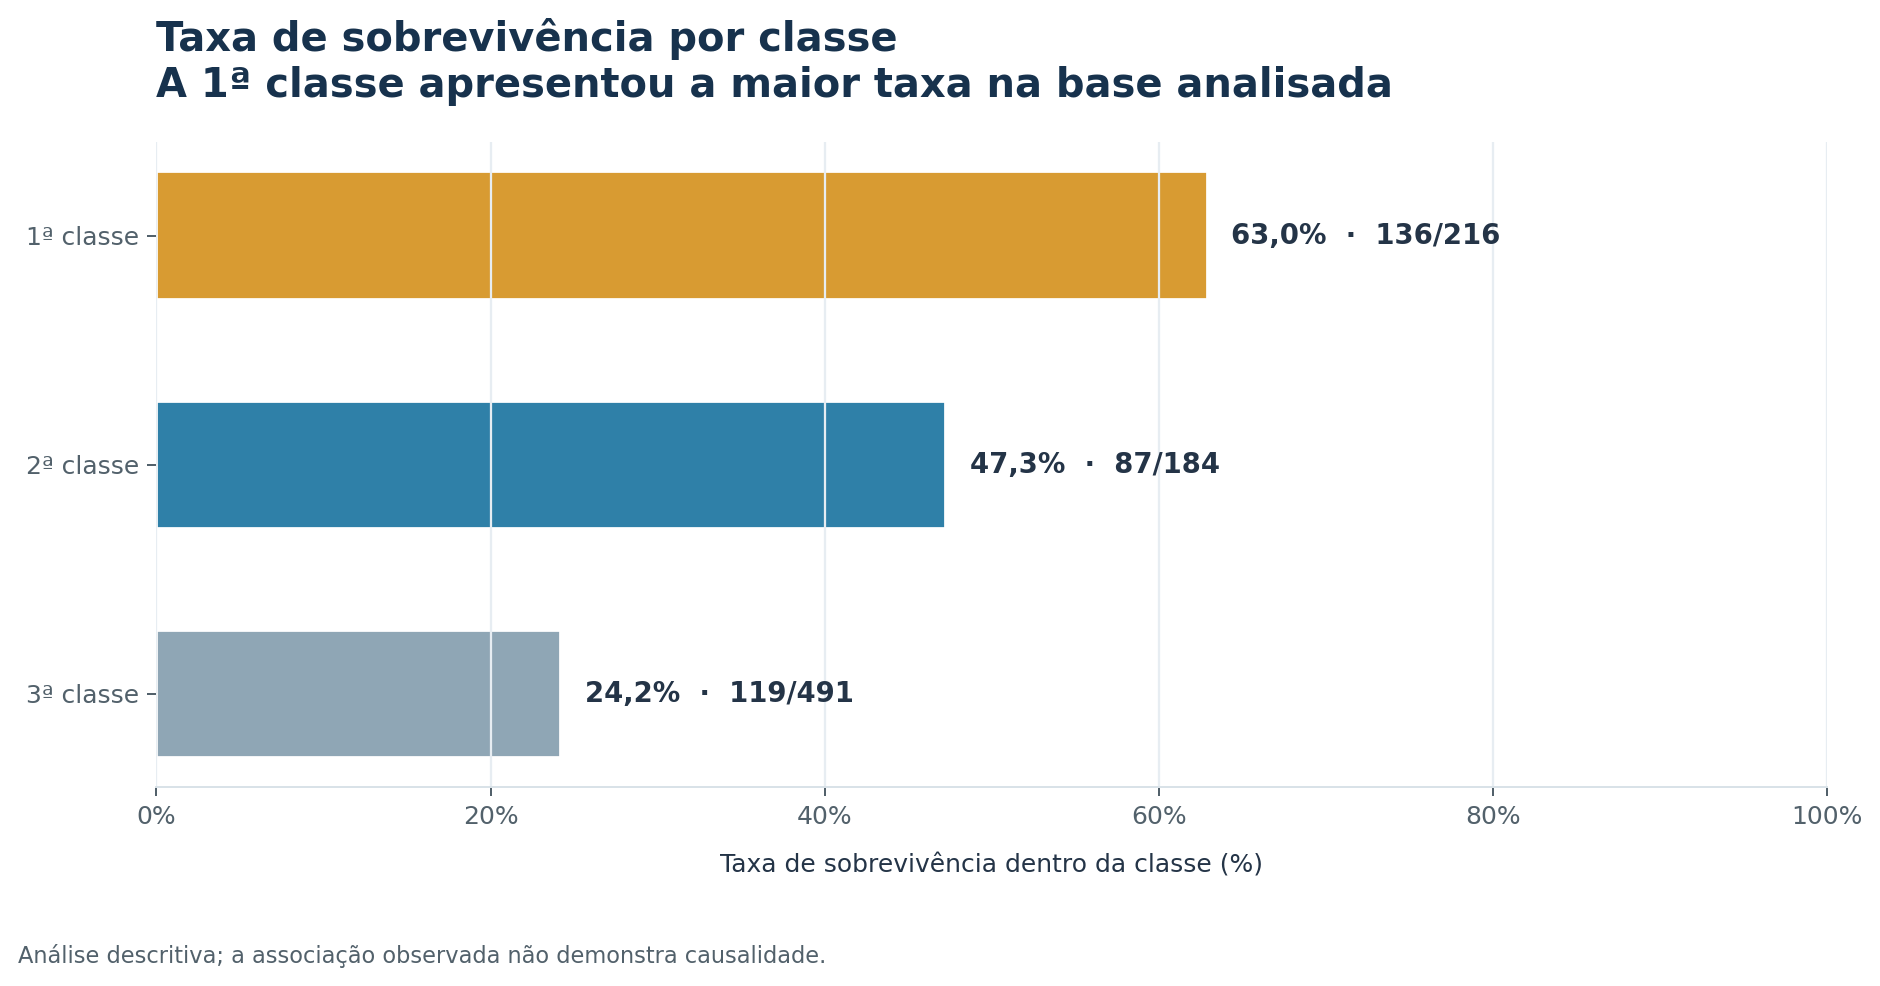

In [ ]:
taxas = contagens["Taxa de sobrevivência (%)"].to_numpy()
classes = ["1ª classe", "2ª classe", "3ª classe"]
cores = [CORES["dourado"], CORES["oceano"], CORES["neutro"]]

fig, ax = plt.subplots(figsize=(10.5, 5.8), facecolor="white")
ax.set_facecolor("white")
barras = ax.barh(classes, taxas, color=cores, height=0.56, edgecolor="white", linewidth=1.5)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Taxa de sobrevivência dentro da classe (%)", labelpad=10)
ax.set_title(
    "Taxa de sobrevivência por classe\n"
    "A 1ª classe apresentou a maior taxa na base analisada",
    loc="left", fontsize=16, color=CORES["marinho"], pad=18,
)
ax.xaxis.set_major_formatter(lambda valor, pos: f"{valor:.0f}%")
ax.grid(axis="x", color="#E7EDF2", linewidth=0.9)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#D9E2E8")

for barra, taxa, classe in zip(barras, taxas, classes):
    linha = contagens.loc[classe]
    texto = f"{pt_numero(taxa, 1)}%  ·  {int(linha['Sobreviveu'])}/{int(linha['Total'])}"
    ax.text(taxa + 1.4, barra.get_y() + barra.get_height() / 2, texto, va="center", fontsize=11, color=CORES["texto"], fontweight="bold")

fig.text(0.01, 0.01, "Análise descritiva; a associação observada não demonstra causalidade.", ha="left", fontsize=9, color="#52616B")
fig.tight_layout(rect=[0, 0.06, 1, 0.94])
pasta_graficos = Path("graficos_final")
pasta_graficos.mkdir(exist_ok=True)
fig.savefig(pasta_graficos / "taxa_sobrevivencia_por_classe.png", bbox_inches="tight", facecolor="white")
plt.show()

**Leitura para a fala:** na 1ª classe, 136 de 216 passageiros sobreviveram, ou 63,0%. Na 2ª, foram 87 de 184, ou 47,3%. Na 3ª, 119 de 491, ou 24,2%. A diferença é uma associação observada nesta base; o gráfico não prova que a classe, isoladamente, causou a sobrevivência.

## 9. Conclusão e limites — Kevin

- As medidas de posição resumiram a distribuição de sobrevivência e dos códigos de classe por perspectivas diferentes.
- O DP e o CV mostraram a dispersão relativa de cada variável, com interpretação cuidadosa para dados binários e ordinais.
- As taxas de sobrevivência foram 63,0% na 1ª classe, 47,3% na 2ª e 24,2% na 3ª.
- A análise descreve os 891 registros do arquivo `train.csv`; não representa necessariamente todos os passageiros do Titanic.
- Associação não é causalidade: outras variáveis e métodos seriam necessários para investigar causas.

**Fonte:** `train.csv`, competição *Titanic - Machine Learning from Disaster*, Kaggle. **Cálculos e gráfico:** Python, com Pandas, NumPy, Matplotlib e Seaborn.

## 10. Validação final do material

A célula seguinte funciona como checklist técnico antes do ensaio e da entrega.

In [ ]:
assert dados.shape == (891, 12)
assert medidas.loc["Sobrevivência", "n"] == 891
assert medidas.loc["Classe de passagem", "n"] == 891
assert round(contagens.loc["1ª classe", "Sobreviveu"]) == 136
assert round(contagens.loc["1ª classe", "Total"]) == 216
assert round(contagens.loc["2ª classe", "Sobreviveu"]) == 87
assert round(contagens.loc["2ª classe", "Total"]) == 184
assert round(contagens.loc["3ª classe", "Sobreviveu"]) == 119
assert round(contagens.loc["3ª classe", "Total"]) == 491
assert np.isclose(contagens.loc["1ª classe", "Taxa de sobrevivência (%)"], 63.0, atol=0.05)
assert np.isclose(contagens.loc["2ª classe", "Taxa de sobrevivência (%)"], 47.3, atol=0.05)
assert np.isclose(contagens.loc["3ª classe", "Taxa de sobrevivência (%)"], 24.2, atol=0.05)
print("[OK] Validação concluída: base, cálculos, taxas e roteiro estão alinhados.")